
# Student Placement Prediction System — PyCaret Edition

This notebook rebuilds the student placement workflow with **PyCaret 3**.

It keeps the same dataset cleaning logic and hold-out test split, then uses:
- `setup()` for preprocessing and experiment setup
- `compare_models(sort='F1')` to rank models
- `finalize_model()` and `predict_model()` for final validation on the test set



## 1) Optional installation

Run this only if PyCaret is not already installed in your environment.


In [2]:

# Optional:
# !pip install pycaret==3.3.2


## 2) Imports and configuration

In [3]:

import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
np.random.seed(42)

TARGET_COL = "Placement(Y/N)?"
RANDOM_STATE = 42
TEST_SIZE = 0.2

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)


## 3) Locate and load the dataset

In [4]:

possible_data_paths = [
    Path("Sample.csv"),
    Path("data") / "Sample.csv",
    Path("/mnt/data/Sample.csv"),
]

for p in possible_data_paths:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Sample.csv not found in the expected locations.")

df_raw = pd.read_csv(DATA_PATH)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())


Dataset shape: (401, 16)


,Email,Name,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,Innovative Project(Y/N),Communication level,Technical Course(Y/N),Placement(Y/N)?
0,payal_roy79@gmail.com,Payal Roy,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,No,Yes,No,No,3,Yes,Not Placed
1,shreyoshi_dey13@gmail.com,Shreyoshi Dey,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,No,No,No,Yes,4,No,Not Placed
2,rohan_nandi12@gmail.com,Rohan Nandi,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,No,Yes,No,Yes,3,Yes,Placed
3,smita_agarwal90@gmail.com,Smita Agarwal,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,Yes,No,Yes,Yes,2,Yes,Not Placed
4,samaira_singhania95@gmail.com,Samaira Singhania,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,Yes,Yes,No,Yes,1,Yes,Not Placed


## 4) Quick inspection

In [5]:

print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df_raw.isna().sum().to_frame("missing_values"))

print("\nTarget distribution:")
display(df_raw[TARGET_COL].value_counts().to_frame("count"))
display((df_raw[TARGET_COL].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))


Column names:
['Email', 'Name', 'Gender', '10th board', '10th marks', '12th board', '12th marks', 'Stream', 'Cgpa', 'Internships(Y/N)', 'Training(Y/N)', 'Backlog in 5th sem', 'Innovative Project(Y/N)', 'Communication level', 'Technical Course(Y/N)', 'Placement(Y/N)?']

Data types:


,dtype
Email,object
Name,object
Gender,object
10th board,object
10th marks,float64
12th board,object
12th marks,float64
Stream,object
Cgpa,float64
Internships(Y/N),object



Missing values:


,missing_values
Email,0
Name,0
Gender,0
10th board,0
10th marks,0
12th board,0
12th marks,0
Stream,0
Cgpa,0
Internships(Y/N),0



Target distribution:


,count
Placement(Y/N)?,
Not Placed,202
Placed,199


,percentage
Placement(Y/N)?,
Not Placed,50.37
Placed,49.63


## 5) Cleaning and feature engineering

In [6]:

def normalize_binary_text(value):
    if pd.isna(value):
        return value
    text = str(value).strip().lower()
    mapping = {
        "yes": "Yes",
        "yess": "Yes",
        "y": "Yes",
        "no": "No",
        "n": "No",
    }
    return mapping.get(text, value)

def clean_dataset(input_df: pd.DataFrame) -> pd.DataFrame:
    df_clean = input_df.copy()

    binary_cols = [
        "Internships(Y/N)",
        "Training(Y/N)",
        "Backlog in 5th sem",
        "Innovative Project(Y/N)",
        "Technical Course(Y/N)",
    ]
    for col in binary_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].apply(normalize_binary_text)

    if "Cgpa" in df_clean.columns:
        df_clean.loc[(df_clean["Cgpa"] < 0) | (df_clean["Cgpa"] > 10), "Cgpa"] = np.nan

    if TARGET_COL in df_clean.columns:
        df_clean[TARGET_COL] = df_clean[TARGET_COL].astype(str).str.strip()

    return df_clean

def add_features(input_df: pd.DataFrame) -> pd.DataFrame:
    df_feat = input_df.copy()

    yes_no_map = {"Yes": 1, "No": 0}
    binary_source_cols = [
        "Internships(Y/N)",
        "Training(Y/N)",
        "Innovative Project(Y/N)",
        "Technical Course(Y/N)",
        "Backlog in 5th sem",
    ]
    for col in binary_source_cols:
        if col in df_feat.columns:
            df_feat[col + "_num"] = df_feat[col].map(yes_no_map)

    if all(col in df_feat.columns for col in ["10th marks", "12th marks", "Cgpa"]):
        df_feat["profile_score"] = (
            0.20 * (df_feat["10th marks"] / 100.0)
            + 0.20 * (df_feat["12th marks"] / 100.0)
            + 0.40 * (df_feat["Cgpa"] / 10.0)
            + 0.10 * df_feat.get("Internships(Y/N)_num", 0)
            + 0.05 * df_feat.get("Training(Y/N)_num", 0)
            + 0.05 * df_feat.get("Innovative Project(Y/N)_num", 0)
        )

    required_cols = [
        "Internships(Y/N)_num",
        "Training(Y/N)_num",
        "Innovative Project(Y/N)_num",
        "Technical Course(Y/N)_num",
        "Backlog in 5th sem_num",
    ]
    if all(col in df_feat.columns for col in required_cols):
        df_feat["experience_index"] = (
            0.30 * df_feat["Internships(Y/N)_num"]
            + 0.20 * df_feat["Training(Y/N)_num"]
            + 0.20 * df_feat["Innovative Project(Y/N)_num"]
            + 0.15 * df_feat["Technical Course(Y/N)_num"]
            - 0.15 * df_feat["Backlog in 5th sem_num"]
        )

    return df_feat

df_clean = clean_dataset(df_raw)
df_feat = add_features(df_clean)

print("Cleaned shape:", df_feat.shape)
display(df_feat.head())


Cleaned shape: (401, 23)


,Email,Name,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,Innovative Project(Y/N),Communication level,Technical Course(Y/N),Placement(Y/N)?,Internships(Y/N)_num,Training(Y/N)_num,Innovative Project(Y/N)_num,Technical Course(Y/N)_num,Backlog in 5th sem_num,profile_score,experience_index
0,payal_roy79@gmail.com,Payal Roy,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,No,Yes,No,No,3,Yes,Not Placed,0,1,0,1,0,0.6786,0.35
1,shreyoshi_dey13@gmail.com,Shreyoshi Dey,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,No,No,No,Yes,4,No,Not Placed,0,0,1,0,0,0.7976,0.20
2,rohan_nandi12@gmail.com,Rohan Nandi,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,No,Yes,No,Yes,3,Yes,Placed,0,1,1,1,0,0.7478,0.55
3,smita_agarwal90@gmail.com,Smita Agarwal,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,Yes,No,Yes,Yes,2,Yes,Not Placed,1,0,1,1,1,0.8138,0.50
4,samaira_singhania95@gmail.com,Samaira Singhania,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,Yes,Yes,No,Yes,1,Yes,Not Placed,1,1,1,1,0,0.8942,0.85


## 6) Prepare features and hold-out split

In [7]:

drop_cols = [c for c in ["Email", "Name"] if c in df_feat.columns]

X = df_feat.drop(columns=drop_cols + [TARGET_COL])
y = df_feat[TARGET_COL]

print("Feature columns:", X.columns.tolist())
print("\nTarget values:")
display(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target ratio:")
display(y_train.value_counts(normalize=True).round(3))


Feature columns: ['Gender', '10th board', '10th marks', '12th board', '12th marks', 'Stream', 'Cgpa', 'Internships(Y/N)', 'Training(Y/N)', 'Backlog in 5th sem', 'Innovative Project(Y/N)', 'Communication level', 'Technical Course(Y/N)', 'Internships(Y/N)_num', 'Training(Y/N)_num', 'Innovative Project(Y/N)_num', 'Technical Course(Y/N)_num', 'Backlog in 5th sem_num', 'profile_score', 'experience_index']

Target values:


Placement(Y/N)?
Not Placed    202
Placed        199
Name: count, dtype: int64

Train shape: (320, 20)
Test shape: (81, 20)
Train target ratio:


Placement(Y/N)?
Not Placed    0.503
Placed        0.497
Name: proportion, dtype: float64

## 7) PyCaret setup

In [8]:

from pycaret.classification import (
    setup,
    compare_models,
    pull,
    predict_model,
    finalize_model,
)

train_df = X_train.copy()
train_df[TARGET_COL] = y_train.values

print("Setting up PyCaret ...")
clf_setup = setup(
    data=train_df,
    target=TARGET_COL,
    session_id=RANDOM_STATE,
    fold=5,
    verbose=True,
)
print("\nPyCaret setup complete ✅")


Setting up PyCaret ...


,Description,Value
0,Session id,42
1,Target,Placement(Y/N)?
2,Target type,Binary
3,Target mapping,"Not Placed: 0, Placed: 1"
4,Original data shape,"(320, 21)"
5,Transformed data shape,"(320, 46)"
6,Transformed train set shape,"(224, 46)"
7,Transformed test set shape,"(96, 46)"
8,Numeric features,11
9,Categorical features,9



PyCaret setup complete ✅


## 8) Compare models

In [9]:

best_models = compare_models(
    sort="F1",
    n_select=5,
)

leaderboard_df = pull()
display(leaderboard_df)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8708,0.8698,0.8708,0.8775,0.8702,0.7418,0.7483,0.1880
gbc,Gradient Boosting Classifier,0.8708,0.8805,0.8708,0.8778,0.8702,0.7418,0.7485,0.1300
catboost,CatBoost Classifier,0.8707,0.8667,0.8707,0.8788,0.8700,0.7418,0.7496,1.1720
et,Extra Trees Classifier,0.8708,0.8773,0.8708,0.8799,0.8699,0.7419,0.7507,0.1320
lr,Logistic Regression,0.8574,0.8929,0.8574,0.8712,0.8559,0.7148,0.7282,1.0720
ridge,Ridge Classifier,0.8486,0.8807,0.8486,0.8692,0.8460,0.6977,0.7176,0.1040
lda,Linear Discriminant Analysis,0.8397,0.8831,0.8397,0.8626,0.8365,0.6802,0.7019,0.0680
lightgbm,Light Gradient Boosting Machine,0.8352,0.8375,0.8352,0.8399,0.8346,0.6706,0.6751,0.1120
nb,Naive Bayes,0.8306,0.8819,0.8306,0.8493,0.8282,0.6617,0.6797,0.0760
dt,Decision Tree Classifier,0.8260,0.8263,0.8260,0.8315,0.8253,0.6521,0.6574,0.0820


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8708,0.8698,0.8708,0.8775,0.8702,0.7418,0.7483,0.188
gbc,Gradient Boosting Classifier,0.8708,0.8805,0.8708,0.8778,0.8702,0.7418,0.7485,0.130
catboost,CatBoost Classifier,0.8707,0.8667,0.8707,0.8788,0.8700,0.7418,0.7496,1.172
et,Extra Trees Classifier,0.8708,0.8773,0.8708,0.8799,0.8699,0.7419,0.7507,0.132
lr,Logistic Regression,0.8574,0.8929,0.8574,0.8712,0.8559,0.7148,0.7282,1.072
ridge,Ridge Classifier,0.8486,0.8807,0.8486,0.8692,0.8460,0.6977,0.7176,0.104
lda,Linear Discriminant Analysis,0.8397,0.8831,0.8397,0.8626,0.8365,0.6802,0.7019,0.068
lightgbm,Light Gradient Boosting Machine,0.8352,0.8375,0.8352,0.8399,0.8346,0.6706,0.6751,0.112
nb,Naive Bayes,0.8306,0.8819,0.8306,0.8493,0.8282,0.6617,0.6797,0.076
dt,Decision Tree Classifier,0.8260,0.8263,0.8260,0.8315,0.8253,0.6521,0.6574,0.082


## 9) Pick the best model

In [10]:

if isinstance(best_models, list):
    best_model = best_models[0]
else:
    best_model = best_models

print("Best model selected:", type(best_model).__name__)


Best model selected: RandomForestClassifier


## 10) Finalize and evaluate on the hold-out test set

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8889,0.9409,0.8889,0.8892,0.8889,0.7778,0.7780


,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,...,Internships(Y/N)_num,Training(Y/N)_num,Innovative Project(Y/N)_num,Technical Course(Y/N)_num,Backlog in 5th sem_num,profile_score,experience_index,Placement(Y/N)?,prediction_label,prediction_score
1,Female,WBBSE,96.199997,WBCHSE,90.599998,Electronics and Communication Engineering,9.35,No,No,No,...,0,0,1,0,0,0.7976,0.20,Not Placed,Not Placed,0.90
205,Male,ICSE,77.599998,ISE,84.599998,Mechanical Engineering,9.12,No,Yes,Yes,...,0,1,0,0,1,0.7392,0.05,Not Placed,Not Placed,0.97
286,Female,CBSE,80.199997,WBCHSE,92.400002,Mechanical Engineering,8.94,Yes,No,No,...,1,0,1,1,0,0.8528,0.65,Placed,Placed,0.89
266,Male,CBSE,95.000000,CBSE,93.199997,Computer Science in AIML,7.21,No,No,No,...,0,0,1,1,0,0.7148,0.35,Placed,Placed,0.81
25,Female,WBBSE,89.300003,CBSE,71.199997,Electronics and Communication Engineering,7.78,Yes,Yes,No,...,1,1,1,1,0,0.8322,0.85,Placed,Placed,0.96


,Accuracy,Precision,Recall,F1 Score
0,0.888889,0.878049,0.9,0.888889



Classification report:
              precision    recall  f1-score   support

  Not Placed       0.90      0.88      0.89        41
      Placed       0.88      0.90      0.89        40

    accuracy                           0.89        81
   macro avg       0.89      0.89      0.89        81
weighted avg       0.89      0.89      0.89        81



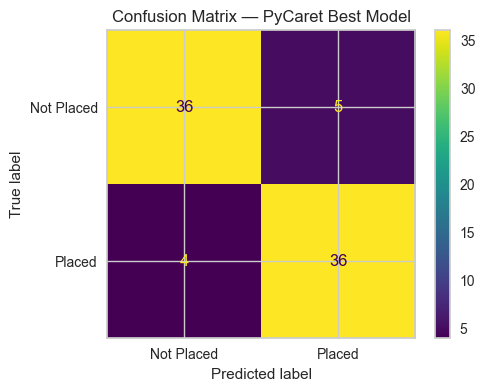

In [11]:

final_model = finalize_model(best_model)

test_df = X_test.copy()
test_df[TARGET_COL] = y_test.values

preds_df = predict_model(final_model, data=test_df)
display(preds_df.head())

label_col = "prediction_label" if "prediction_label" in preds_df.columns else "Label"

y_pred = preds_df[label_col].astype(str)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, pos_label="Placed"),
    "Recall": recall_score(y_test, y_pred, pos_label="Placed"),
    "F1 Score": f1_score(y_test, y_pred, pos_label="Placed"),
}
metrics_df = pd.DataFrame([metrics])
display(metrics_df)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not Placed", "Placed"]))

cm = confusion_matrix(y_test, y_pred, labels=["Not Placed", "Placed"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Placed", "Placed"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Confusion Matrix — PyCaret Best Model")
plt.show()


## 11) Save the final model and predictions

In [12]:

MODEL_PATH = MODEL_DIR / "best_pycaret_model.pkl"
PRED_PATH = MODEL_DIR / "pycaret_holdout_predictions.csv"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(final_model, f)

preds_df.to_csv(PRED_PATH, index=False)

print("Saved:", MODEL_PATH)
print("Saved:", PRED_PATH)


Saved: models\best_pycaret_model.pkl
Saved: models\pycaret_holdout_predictions.csv


## 12) Simple inference helper

In [13]:

def predict_single_row(row_dict: dict):
    # Predict placement status for one record.
    # Provide a dict with the same feature columns used in X.
    row_df = pd.DataFrame([row_dict])
    row_df = add_features(clean_dataset(row_df))
    pred = predict_model(final_model, data=row_df)
    return pred

# Example:
# sample_input = X_test.iloc[0].to_dict()
# predict_single_row(sample_input)



## End

This notebook is ready to run on the same dataset structure as the original project.
